<a href="https://colab.research.google.com/github/HappyRainiNg/rain-data-ai-portfolio/blob/main/task-002-pandas-cleaning-practice/pandas_cleaning_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 002 — Pandas Cleaning Practice

In this notebook, I use pandas to clean a mock seafood sales dataset for Eat Well.

The main steps are:

1. Read the CSV file
2. Inspect the data
3. Clean text columns and Create new columns
4. Build summary tables
5. Generate CSV file
6. Generate Bar Chart

# STEP 1: Read the CSV file

In [25]:
import pandas as pd

df = pd.read_csv("data/eatwell_sales_sample.csv")

df.head()

,order_id,order_date,customer_type,product,category,quantity_kg,unit_price_hkd,district,payment_method
0,E001,2026-06-01,Retail,salmon,Fish,2.5,128,Central,cash
1,E002,2026-06-01,Wholesale,Shrimp,Shellfish,5.0,168,Mong Kok,fps
2,E003,2026-06-02,Retail,CRAB,Shellfish,3.2,238,Sha Tin,card
3,E004,2026-06-03,Retail,oyster,Shellfish,1.5,48,Tuen Mun,cash
4,E005,2026-06-04,Wholesale,scallop,Shellfish,4.0,98,Kwun Tong,FPS


# STEP 2: Inspect the data

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        20 non-null     object 
 1   order_date      20 non-null     object 
 2   customer_type   20 non-null     object 
 3   product         20 non-null     object 
 4   category        20 non-null     object 
 5   quantity_kg     20 non-null     float64
 6   unit_price_hkd  20 non-null     int64  
 7   district        20 non-null     object 
 8   payment_method  20 non-null     object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.5+ KB


In [27]:
df.describe()

,quantity_kg,unit_price_hkd
count,20.000000,20.000000
mean,3.350000,175.000000
std,1.816156,108.390134
min,1.200000,48.000000
25%,1.950000,98.000000
50%,2.600000,148.000000
75%,4.850000,238.000000
max,7.000000,388.000000


In [28]:
df.isna().sum()

,0
order_id,0
order_date,0
customer_type,0
product,0
category,0
quantity_kg,0
unit_price_hkd,0
district,0
payment_method,0


In [29]:
df.duplicated().sum()

np.int64(0)

## Initial Observations

The dataset contains mock seafood sales records.

Some product names have inconsistent formatting, such as extra spaces and different letter cases.  
The order_date column should be converted to datetime format.  
A new sales_amount_hkd column should be calculated using quantity_kg and unit_price_hkd.

# STEP 3: Clean text columns and Create new columns

In [30]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["product"] = df["product"].str.strip().str.lower()
df["district"] = df["district"].str.strip().str.title()
df["payment_method"] = df["payment_method"].str.strip().str.upper()

df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["sales_amount_hkd"] = df["quantity_kg"] * df["unit_price_hkd"]

df.head()

,order_id,order_date,customer_type,product,category,quantity_kg,unit_price_hkd,district,payment_method,month,sales_amount_hkd
0,E001,2026-06-01,Retail,salmon,Fish,2.5,128,Central,CASH,2026-06,320.0
1,E002,2026-06-01,Wholesale,shrimp,Shellfish,5.0,168,Mong Kok,FPS,2026-06,840.0
2,E003,2026-06-02,Retail,crab,Shellfish,3.2,238,Sha Tin,CARD,2026-06,761.6
3,E004,2026-06-03,Retail,oyster,Shellfish,1.5,48,Tuen Mun,CASH,2026-06,72.0
4,E005,2026-06-04,Wholesale,scallop,Shellfish,4.0,98,Kwun Tong,FPS,2026-06,392.0


In [31]:
df.isna().sum()

,0
order_id,0
order_date,0
customer_type,0
product,0
category,0
quantity_kg,0
unit_price_hkd,0
district,0
payment_method,0
month,0


In [32]:
df[["quantity_kg", "unit_price_hkd", "sales_amount_hkd"]].describe()

,quantity_kg,unit_price_hkd,sales_amount_hkd
count,20.000000,20.000000,20.000000
mean,3.350000,175.000000,539.050000
std,1.816156,108.390134,321.771006
min,1.200000,48.000000,72.000000
25%,1.950000,98.000000,313.600000
50%,2.600000,148.000000,504.700000
75%,4.850000,238.000000,714.200000
max,7.000000,388.000000,1176.000000


# STEP 4: Build summary tables

In [33]:
product_summary = df.groupby("product").agg(
    total_quantity_kg=("quantity_kg", "sum"),
    total_sales_hkd=("sales_amount_hkd", "sum"),
    avg_unit_price_hkd=("unit_price_hkd", "mean"),
    order_count=("order_id", "count")
).reset_index()

product_summary

,product,total_quantity_kg,total_sales_hkd,avg_unit_price_hkd,order_count
0,crab,8.4,1999.2,238.0,3
1,lobster,4.5,1746.0,388.0,3
2,oyster,5.5,264.0,48.0,3
3,salmon,9.8,1254.4,128.0,4
4,scallop,14.3,1401.4,98.0,3
5,shrimp,24.5,4116.0,168.0,4


In [34]:
monthly_summary = df.groupby("month").agg(
    total_sales_hkd=("sales_amount_hkd", "sum"),
    total_quantity_kg=("quantity_kg", "sum"),
    order_count=("order_id", "count")
    ).reset_index()

monthly_summary

,month,total_sales_hkd,total_quantity_kg,order_count
0,2026-06,10781.0,67.0,20


In [35]:
district_summary = df.groupby("district").agg(
    total_sales_hkd=("sales_amount_hkd", "sum"),
    order_count=("order_id", "count")
).reset_index()

district_summary

,district,total_sales_hkd,order_count
0,Central,1923.0,3
1,Fo Tan,1432.0,2
2,Kowloon City,2174.4,3
3,Kwun Tong,1152.0,3
4,Mong Kok,1569.0,3
5,Sha Tin,1337.6,3
6,Tuen Mun,1193.0,3


# STEP 5: Generate CSV files

In [36]:
import os
os.makedirs("outputs", exist_ok=True)

product_summary.to_csv("outputs/product_sales_summary.csv", index=False)
monthly_summary.to_csv("outputs/monthly_sales_summary.csv", index=False)
district_summary.to_csv("outputs/district_sales_summary.csv", index=False)

# STEP 6: Generate Bar Chart

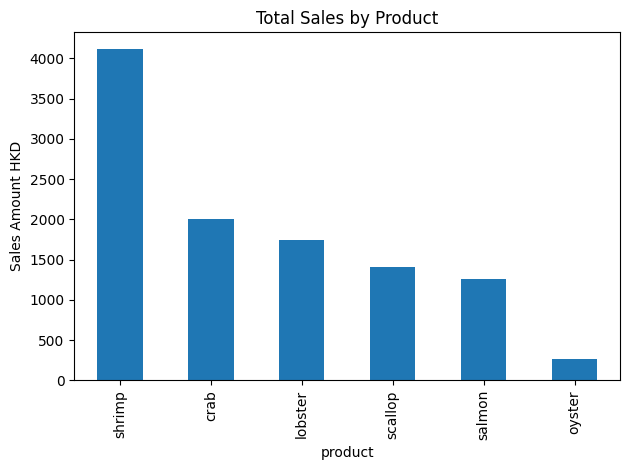

In [37]:
import matplotlib.pyplot as plt

product_summary.sort_values("total_sales_hkd", ascending=False).plot(
    x="product",
    y="total_sales_hkd",
    kind="bar",
    legend=False,
    title="Total Sales by Product"
)

plt.ylabel("Sales Amount HKD")
plt.tight_layout()
plt.savefig("outputs/total_sales_by_product.png", dpi=150)
plt.show()